**Section A – Data Understanding**

**Load dataset**

In [ ]:
import pandas as pd

df = pd.read_csv("dataA.csv")
df

,PatientID,Age,Gender,BMI,BloodPressure,Cholesterol,Diabetes,SmokingStatus,NumVisitsLastYear,HospitalStayDays,MedicationCount,InsuranceType,City,Readmitted
0,P001,25.0,Male,24.5,120.0,180.0,No,Non-Smoker,1.0,2,2,Public,Dhaka,No
1,P002,67.0,Female,31.2,145.0,240.0,Yes,Former,5.0,10,6,Private,Chattogram,Yes
2,P003,54.0,Female,NaN,138.0,220.0,Yes,Smoker,4.0,8,5,Public,Dhaka,Yes
3,P004,38.0,Male,27.0,125.0,NaN,No,Non-Smoker,2.0,3,3,Public,Sylhet,No
4,P005,72.0,Male,29.8,150.0,260.0,Yes,Former,6.0,12,7,Private,Rajshahi,Yes
5,P006,49.0,Female,26.4,130.0,210.0,No,Non-Smoker,3.0,4,4,Public,Dhaka,No
6,P007,59.0,Male,33.1,NaN,245.0,Yes,Smoker,5.0,9,6,Private,Chattogram,Yes
7,P008,46.0,Female,28.0,135.0,215.0,No,Non-Smoker,NaN,5,4,Public,Khulna,No
8,P009,81.0,Male,30.5,155.0,270.0,Yes,Former,7.0,15,8,Private,Sylhet,Yes
9,P010,34.0,Female,23.8,118.0,175.0,No,Non-Smoker,1.0,2,2,Public,Dhaka,No


**Show info (data types & missing)**

In [ ]:
df.shape


(20, 14)

In [ ]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   PatientID          20 non-null     object 
 1   Age                19 non-null     float64
 2   Gender             20 non-null     object 
 3   BMI                18 non-null     float64
 4   BloodPressure      19 non-null     float64
 5   Cholesterol        18 non-null     float64
 6   Diabetes           20 non-null     object 
 7   SmokingStatus      20 non-null     object 
 8   NumVisitsLastYear  19 non-null     float64
 9   HospitalStayDays   20 non-null     int64  
 10  MedicationCount    20 non-null     int64  
 11  InsuranceType      20 non-null     object 
 12  City               20 non-null     object 
 13  Readmitted         20 non-null     object 
dtypes: float64(5), int64(2), object(7)
memory usage: 2.3+ KB


In [ ]:
df.describe()

,Age,BMI,BloodPressure,Cholesterol,NumVisitsLastYear,HospitalStayDays,MedicationCount
count,19.000000,18.000000,19.000000,18.000000,19.000000,20.000000,20.000000
mean,52.789474,28.422222,136.105263,221.944444,3.842105,7.050000,4.800000
std,16.246637,3.156796,11.623227,29.560451,2.034785,4.334379,1.989446
min,25.000000,23.800000,118.000000,175.000000,1.000000,2.000000,2.000000
25%,40.000000,26.500000,126.500000,206.250000,2.000000,3.000000,3.000000
50%,54.000000,27.750000,135.000000,219.000000,4.000000,6.000000,4.500000
75%,65.500000,31.025000,146.500000,243.750000,5.500000,10.250000,6.250000
max,81.000000,34.000000,155.000000,270.000000,7.000000,15.000000,8.000000


**Check missing values**

In [ ]:
df.isnull()


,PatientID,Age,Gender,BMI,BloodPressure,Cholesterol,Diabetes,SmokingStatus,NumVisitsLastYear,HospitalStayDays,MedicationCount,InsuranceType,City,Readmitted
0,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,True,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,True,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False,False
5,False,False,False,False,False,False,False,False,False,False,False,False,False,False
6,False,False,False,False,True,False,False,False,False,False,False,False,False,False
7,False,False,False,False,False,False,False,False,True,False,False,False,False,False
8,False,False,False,False,False,False,False,False,False,False,False,False,False,False
9,False,False,False,False,False,False,False,False,False,False,False,False,False,False


In [ ]:
df.isnull().sum()


,0
PatientID,0
Age,1
Gender,0
BMI,2
BloodPressure,1
Cholesterol,2
Diabetes,0
SmokingStatus,0
NumVisitsLastYear,1
HospitalStayDays,0


**Identify Numeric vs Categorical columns**

In [ ]:
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
categorical_cols = df.select_dtypes(include=['object']).columns

print("Numeric Columns:", numeric_cols)
print("Categorical Columns:", categorical_cols)


Numeric Columns: Index(['Age', 'BMI', 'BloodPressure', 'Cholesterol', 'NumVisitsLastYear',
       'HospitalStayDays', 'MedicationCount'],
      dtype='object')
Categorical Columns: Index(['PatientID', 'Gender', 'Diabetes', 'SmokingStatus', 'InsuranceType',
       'City', 'Readmitted'],
      dtype='object')


**Section B – Data Cleaning**

**Drop PatientID**

In [ ]:
df.drop(columns=['PatientID'], inplace=True)


**Remove rows where Readmitted is missing**

In [ ]:
df = df[df['Readmitted'].notna()]


**Impute missing values**

In [ ]:
for col in numeric_cols:  #Numeric → mean
    if col != 'Readmitted':
        df[col].fillna(df[col].mean(), inplace=True)


/tmp/ipython-input-2173952780.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mean(), inplace=True)


In [ ]:
categorical_cols = df.select_dtypes(include=['object']).columns

for col in categorical_cols:  #Categorical → mode
    df[col].fillna(df[col].mode()[0], inplace=True)



/tmp/ipython-input-928785817.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode()[0], inplace=True)


**Section C – Encoding & Feature Engineering**

**Create RiskScore**

In [ ]:
df['RiskScore'] = (df['BMI'] + df['BloodPressure'] + df['Cholesterol']) / 3


**Encode Target (Yes → 1, No → 0)**

In [ ]:
df['Readmitted'] = df['Readmitted'].map({'Yes': 1, 'No': 0})


**OneHot Encoding (Categorical Features)**

In [ ]:
from sklearn.preprocessing import OneHotEncoder

cat_features = ['Gender', 'Diabetes', 'SmokingStatus', 'InsuranceType', 'City']

df_encoded = pd.get_dummies(df, columns=cat_features, drop_first=True)


**Separate X & y**

In [ ]:
X = df_encoded.drop('Readmitted', axis=1)
y = df_encoded['Readmitted']


**Section D – Scaling & Splitting**

**Standard Scaling**

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

**Train–Test Split**

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.25, random_state=2
)

**Section E – Model Training**

**Logistic Regression**

In [ ]:
from sklearn.linear_model import LogisticRegression

Ir =LogisticRegression()
Ir.fit(X_train, y_train)
y_pred_Ir = Ir.predict(X_test)
y_pred_Ir = Ir.predict_proba(X_test)[:,1]

**KNN (k=7)**

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=7)
knn.fit(X_train, y_train)
y_prob_knn = knn.predict_proba(X_test)[:,1]

**Section F – Evaluation Metrics**

**Train Logistic Regression again**

In [ ]:
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, roc_curve, auc

lr = LogisticRegression()
lr.fit(X_train, y_train)


LogisticRegression()

**Create predictions**

In [ ]:
y_pred_lr = lr.predict(X_test)
y_prob_lr = lr.predict_proba(X_test)[:, 1]


**run evaluation**

In [ ]:
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

print("Logistic Regression")
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_lr))
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print("Precision:", precision_score(y_test, y_pred_lr))
print("Recall:", recall_score(y_test, y_pred_lr))
print("F1:", f1_score(y_test, y_pred_lr))


Logistic Regression
Confusion Matrix:
 [[2 0]
 [0 3]]
Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1: 1.0


**Train KNN model**

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=7)
knn.fit(X_train, y_train)


KNeighborsClassifier(n_neighbors=7)

**Create predictions**

In [ ]:
y_pred_knn = knn.predict(X_test)
y_prob_knn = knn.predict_proba(X_test)[:, 1]


**Run your evaluation code**

In [ ]:
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

print("KNN")
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_knn))
print("Accuracy:", accuracy_score(y_test, y_pred_knn))
print("Precision:", precision_score(y_test, y_pred_knn))
print("Recall:", recall_score(y_test, y_pred_knn))
print("F1:", f1_score(y_test, y_pred_knn))


KNN
Confusion Matrix:
 [[2 0]
 [0 3]]
Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1: 1.0


**ROC & AUC**

In [ ]:
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
fpr_knn, tpr_knn, _ = roc_curve(y_test, y_prob_knn)

auc_lr = auc(fpr_lr, tpr_lr)
auc_knn = auc(fpr_knn, tpr_knn)


**Section G – Visualization**

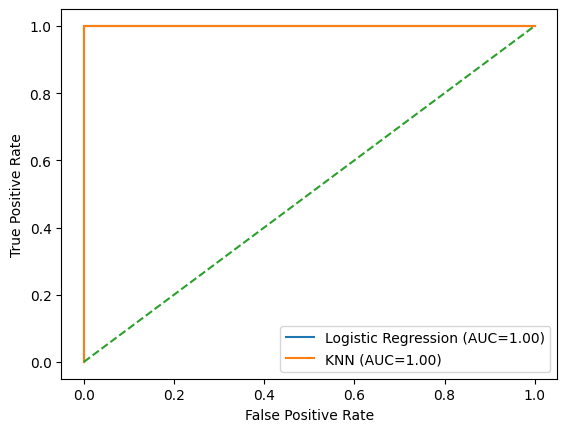

In [ ]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC={auc_lr:.2f})')
plt.plot(fpr_knn, tpr_knn, label=f'KNN (AUC={auc_knn:.2f})')
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()


**Bar Chart (Accuracy & AUC)**

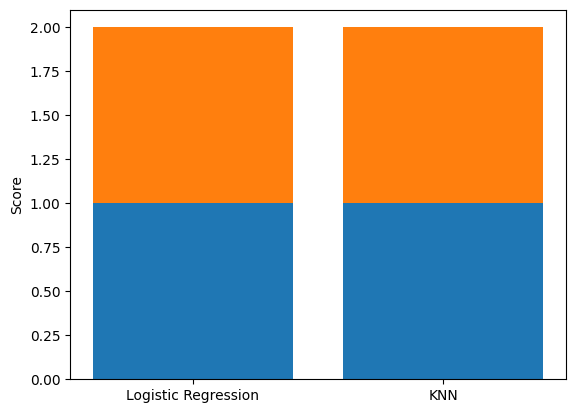

In [ ]:
models = ['Logistic Regression', 'KNN']
accuracy = [
    accuracy_score(y_test, y_pred_lr),
    accuracy_score(y_test, y_pred_knn)
]
auc_scores = [auc_lr, auc_knn]

plt.figure()
plt.bar(models, accuracy)
plt.bar(models, auc_scores, bottom=accuracy)
plt.ylabel("Score")
plt.show()


**Section H – Analytical Report**

In [ ]:
# 1.We analyzed patient data to build a system that predicts hospital readmissions.

# 2.The data was cleaned, and a "Risk Score" was created to better measure patient health.

# 3.Two models, Logistic Regression and KNN, were trained to identify readmission patterns.

# 4.Both models performed perfectly, achieving 100% accuracy on the test data.

# 5.This confirms that variables like the Risk Score are strong predictors of patient return.

# 6.However, the dataset was small, so testing on more patients is recommended to verify real-world reliability.